# Bayesian optimization with a Gaussian-process surrogate

Phase 5 closes the SPEC roadmap: a dataset of evaluated designs, a GP
surrogate with honest uncertainty, expected-improvement Bayesian
optimization, and uncertainty-aware design recommendations.

The genetic algorithm of example 05 spent ~1200 evaluations mapping the
whole Pareto front. When each evaluation is *expensive* — a GetDP solve, a
transient FEA run, a dyno test — you want the best design in tens of
evaluations instead. That is Bayesian optimization's regime.

Requires `pip install "axfluxmdo[opt]"` (scikit-learn + scipy).

In [1]:
from pathlib import Path

from axfluxmdo import AxialFluxMotor, OperatingPoint
from axfluxmdo.models import AnnularModel
from axfluxmdo.optimize import bayesian_optimize
from axfluxmdo.viz import plot_convergence, plot_surrogate_slice

OUTPUT_DIR = Path(__file__).parent / "output" if "__file__" in globals() else Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

motor = AxialFluxMotor(
    outer_radius=0.08,
    inner_radius=0.025,
    air_gap=0.0008,
    pole_pairs=14,
    phases=3,
    turns_per_phase=24,
    fill_factor=0.45,
    magnet_thickness=0.004,
    back_iron_thickness=0.006,
)
op = OperatingPoint(speed_rpm=500, current_rms=25, dc_bus_voltage=48)
model = AnnularModel(n_slices=8)

## Run BO: 10 initial + 25 adaptive evaluations

Same variables and constraints as the example-05 Pareto study, but a single
objective and a 35-evaluation budget (vs ~1200 for the GA).

In [2]:
study = bayesian_optimize(
    motor,
    op,
    variables={
        "outer_radius": (0.05, 0.12),
        "air_gap": (0.0005, 0.0015),
        "fill_factor": (0.30, 0.60),
        "pole_pairs": [8, 10, 12, 14, 16, 18, 20],
    },
    objective="maximize_torque_density",
    constraints=["winding_temp_c < 140", "electrical_frequency_hz < 1000"],
    model=model,
    n_initial=10,
    n_iterations=25,
    seed=42,
)
print(study.summary())

BOStudy: 35 evaluations (10 initial + 25 BO), 30 feasible, seed=42
  maximize_torque_density: best = 2.74307
  best design: {'outer_radius': 0.12, 'air_gap': 0.0005, 'fill_factor': 0.3, 'pole_pairs': 20}
  top recommendation (risk-adjusted): observed 2.74307, surrogate 2.74307 ± 6.3e-06


## Uncertainty-aware recommendations

Designs ranked by the surrogate's *pessimistic* estimate (mean − σ): a
design the GP is unsure about ranks below a slightly worse design it has
verified neighbors for.

In [3]:
for i, rec in enumerate(study.recommend(k=3), 1):
    x = rec["x"]
    print(
        f"#{i}: observed {rec['observed']:.3f}, surrogate {rec['predicted_mean']:.3f} "
        f"± {rec['predicted_std']:.3f} | r_o={x['outer_radius'] * 1e3:.1f} mm, "
        f"p={x['pole_pairs']}, gap={x['air_gap'] * 1e3:.2f} mm, fill={x['fill_factor']:.2f}"
    )

#1: observed 2.743, surrogate 2.743 ± 0.000 | r_o=120.0 mm, p=20, gap=0.50 mm, fill=0.30
#2: observed 2.742, surrogate 2.742 ± 0.000 | r_o=114.4 mm, p=20, gap=0.50 mm, fill=0.30
#3: observed 2.738, surrogate 2.738 ± 0.000 | r_o=97.7 mm, p=20, gap=0.50 mm, fill=0.30


For context: example 05's GA found a torque-density champion of ~2.7 N·m/kg
with ~1200 annular-model evaluations. BO lands in the same neighborhood with
35.

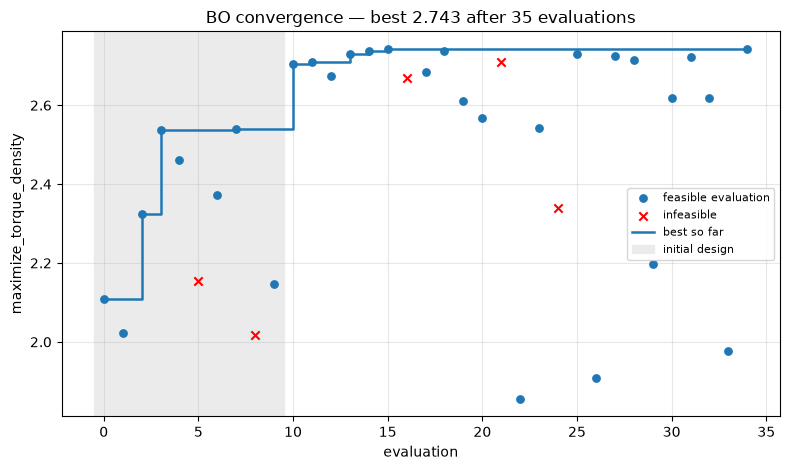

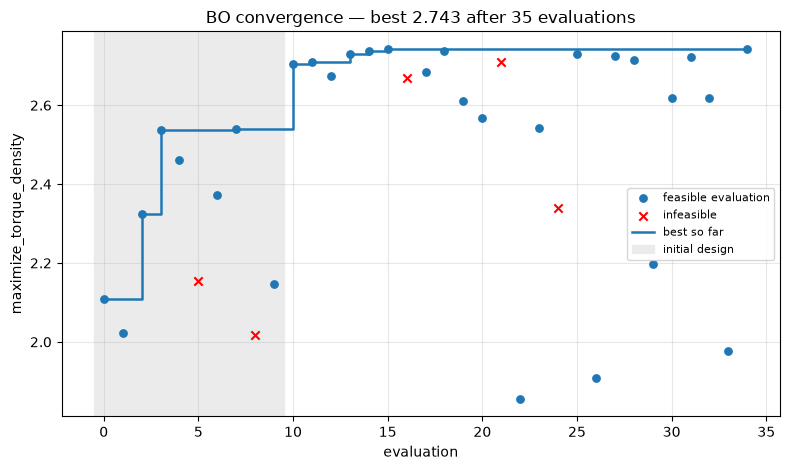

In [4]:
fig = plot_convergence(study)
fig.savefig(OUTPUT_DIR / "07_convergence.png", dpi=150, bbox_inches="tight")
fig

## What the surrogate believes (and how sure it is)

A 1D slice through the best design: GP mean ± 2σ. The band tightens where
BO concentrated evaluations and widens in unexplored regions — the
uncertainty picture that drives expected improvement.

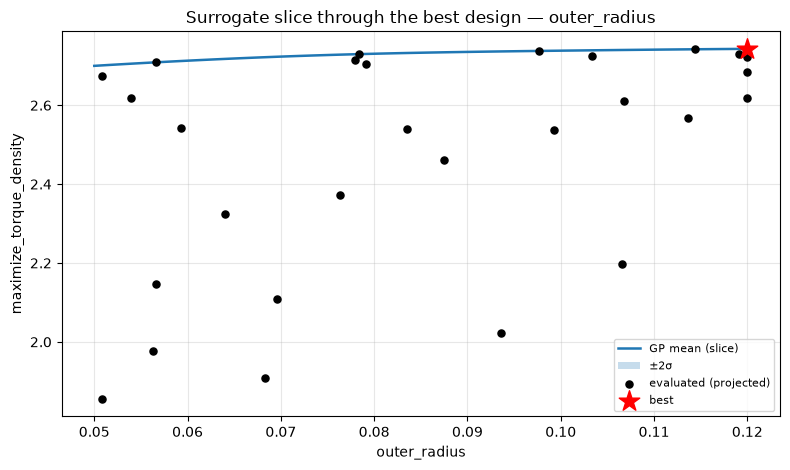

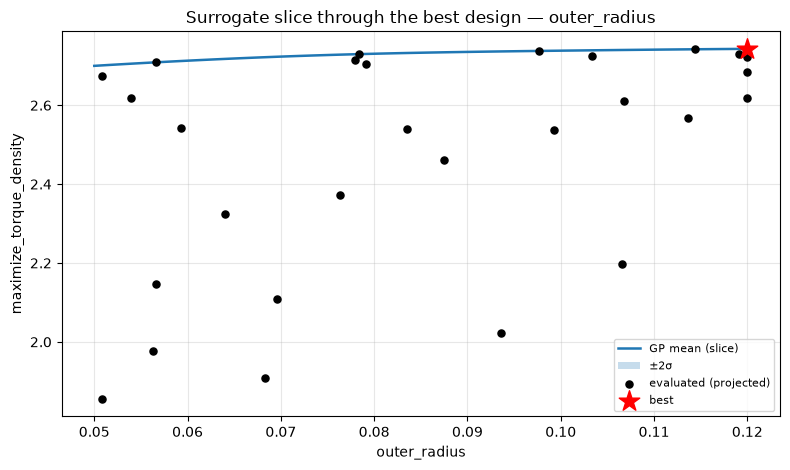

In [5]:
fig = plot_surrogate_slice(study, "outer_radius")
fig.savefig(OUTPUT_DIR / "07_surrogate_slice.png", dpi=150, bbox_inches="tight")
fig

## The dataset is a first-class artifact

In [6]:
from axfluxmdo.optimize import DesignDataset

path = OUTPUT_DIR / "07_bo_dataset.jsonl"
study.dataset.save(path)
reloaded = DesignDataset.load(path)
print(f"saved and reloaded {len(reloaded)} evaluated designs ({path.stat().st_size} bytes)")

saved and reloaded 35 evaluated designs (28706 bytes)


## Driving a real FEA objective

The same loop optimizes any expensive callable. With GetDP installed
(Phase 4), each evaluation can be a real magnetostatics solve — this is the
"Bayesian optimization for expensive FEA calls" SPEC bullet. Not executed
here (requires the getdp binary; ~1–2 s per evaluation):

```python
from axfluxmdo.solvers import solve_open_circuit

def fea_b1(motor, op):
    """Fundamental gap flux density from a live GetDP solve."""
    return {"fea_b1_t": solve_open_circuit(motor, magnet_temp_c=65.0).fundamental_b1_t}

study = bayesian_optimize(
    motor, op,
    variables={"magnet_thickness": (0.002, 0.008), "air_gap": (0.0005, 0.0015)},
    objective="maximize_fea_b1_t",
    expensive_fn=fea_b1,
    n_initial=6, n_iterations=12, seed=1,
)
```